# Detector threshold sensitivity analysis

What each detector's threshold costs and buys, measured rather than asserted.

The numbers come from `research/sweep_metrics.csv` and
`research/case_outcomes.csv`, written by
`uv run python scripts/run_sensitivity_sweep.py`. The method — what the corpus
is, how cases are labelled, and why the window axis is the evaluation interval
rather than the per-detector `time_window_seconds` — is in
`docs/SENSITIVITY_ANALYSIS.md`. The conclusions and the recommended defaults
are in `docs/DETECTION_TUNING.md`.

This notebook is the working between them. Run it with:

```bash
uv sync --all-groups
uv run jupyter lab notebooks/detection_analysis.ipynb
```

Everything it computes comes from `scripts/sensitivity/analysis.py`, so the
tables here and the figures in `docs/images/` cannot disagree.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

from sensitivity.analysis import (
    SHIPPED_WINDOW,
    best_operating_points,
    load_metrics,
    load_outcomes,
    shipped_operating_points,
    window_sensitivity,
)
from sensitivity.corpus import CORPUS

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

metrics = load_metrics()
outcomes = load_outcomes()
print(f"{len(metrics):,} grid points over {len(CORPUS)} cases")

777 grid points over 49 cases


## 1. The corpus

Half the corpus is benign traffic shaped like an attack. Without it every
precision figure would be 1.0 by construction — there would be nothing present
that *could* be mistaken for an attack.

In [2]:
composition = pd.DataFrame(
    [
        {"family": case.family, "case": case.name, "labelled_for": ", ".join(sorted(case.expected)) or "—"}
        for case in CORPUS
    ]
)
composition.groupby("family").agg(
    cases=("case", "count"),
    positives=("labelled_for", lambda column: (column != "—").sum()),
)

,cases,positives
family,,
arp,3,2
baseline,3,1
beaconing,6,3
credentials,7,4
dns,5,2
exfiltration,8,4
flood,10,6
recon,7,4


## 2. What ships

The configured threshold, at the window production actually runs with. Not the
per-detector `time_window_seconds` — nothing reads that field. Detector state
is cleared by `evaluate()`, and `PeriodicEvaluator` calls it on one shared
timer taken from `detection.evaluation_interval_seconds`, which ships at 5.0
seconds.

An empty `f1` means the detector never fired at all: it has no precision, so
there is no balance to strike.

In [3]:
shipped = shipped_operating_points(metrics)
shipped[
    ["threshold", "true_positives", "false_positives", "false_negatives", "precision", "recall", "f1"]
]

,threshold,true_positives,false_positives,false_negatives,precision,recall,f1
detector,,,,,,,
ArpSpoofingDetector,5,1,0,1,1.000000,0.500000,0.666667
BeaconingDetector,10,0,0,3,NaN,0.000000,NaN
DataExfiltrationDetector,50000000,0,0,2,NaN,0.000000,NaN
DnsTunnelingDetector,50,0,0,2,NaN,0.000000,NaN
HttpBruteForceDetector,20,0,0,2,NaN,0.000000,NaN
IcmpFloodDetector,50,2,0,0,1.000000,1.000000,1.000000
LateralMovementDetector,20,0,0,2,NaN,0.000000,NaN
SshBruteForceDetector,10,1,0,1,1.000000,0.500000,0.666667
SynFloodDetector,100,2,1,0,0.666667,1.000000,0.800000


Five of the twelve swept detectors have a recall of 0.00 against their own
attacks, and three more sit at or below 0.5. That is not a tuning problem: each
of them is configured for a window of 60 to 3600 seconds and is being run with
a window of five.

In [4]:
blind = shipped[shipped["recall"] == 0].index.tolist()
print(f"Silent at the shipped configuration ({len(blind)} of {len(shipped)}):")
for name in blind:
    print(" ", name)

Silent at the shipped configuration (5 of 12):
  BeaconingDetector
  DataExfiltrationDetector
  DnsTunnelingDetector
  HttpBruteForceDetector
  LateralMovementDetector


## 3. The window dominates the threshold

The best F1 each detector can reach at each window. Read across a row: if the
row is flat, the detector is tunable by threshold alone. If it climbs, no
threshold rescues it — the window is the binding constraint.

In [5]:
sensitivity = window_sensitivity(metrics)
sensitivity.round(2)

window_seconds,1.0,5.0,10.0,30.0,60.0,300.0,3600.0
detector,,,,,,,
ArpSpoofingDetector,0.67,0.80,0.80,0.80,0.80,0.80,0.80
BeaconingDetector,NaN,NaN,NaN,0.50,0.50,0.75,0.75
DataExfiltrationDetector,NaN,0.67,0.67,0.67,0.80,0.80,0.80
DnsTunnelingDetector,NaN,0.50,0.67,0.80,0.80,0.80,0.80
HttpBruteForceDetector,NaN,0.67,0.67,0.80,0.80,0.80,0.80
IcmpFloodDetector,1.00,1.00,1.00,1.00,1.00,0.80,0.80
LateralMovementDetector,NaN,0.67,0.80,0.80,0.80,0.80,0.80
SshBruteForceDetector,0.67,0.67,0.80,0.67,0.67,0.80,0.80
SynFloodDetector,1.00,0.80,0.80,0.80,0.80,0.80,0.80


In [6]:
cost_of_the_window = pd.DataFrame(
    {
        "f1_at_5s": sensitivity[SHIPPED_WINDOW],
        "best_f1_any_window": sensitivity.max(axis=1),
    }
)
cost_of_the_window["gap"] = (
    cost_of_the_window["best_f1_any_window"] - cost_of_the_window["f1_at_5s"]
)
# A missing f1_at_5s is not a small gap, it is the largest one: the detector
# never fired at that window, so it has no score to be behind by.
cost_of_the_window.sort_values("gap", ascending=False, na_position="first").round(2)

,f1_at_5s,best_f1_any_window,gap
detector,,,
BeaconingDetector,NaN,0.75,NaN
DnsTunnelingDetector,0.50,0.80,0.30
SynFloodDetector,0.80,1.00,0.20
DataExfiltrationDetector,0.67,0.80,0.13
SshBruteForceDetector,0.67,0.80,0.13
HttpBruteForceDetector,0.67,0.80,0.13
LateralMovementDetector,0.67,0.80,0.13
SynScanDetector,0.80,0.86,0.06
TcpPortScanDetector,0.86,0.89,0.03


## 4. Where each detector is best

Ties are broken toward the higher threshold and then the shorter window: among
configurations that score the same, prefer the one that alerts less and decides
sooner.

In [7]:
best = best_operating_points(metrics)
best[["parameter", "threshold", "window_seconds", "precision", "recall", "false_positive_rate", "f1"]]

,parameter,threshold,window_seconds,precision,recall,false_positive_rate,f1
detector,,,,,,,
ArpSpoofingDetector,gratuitous_arp_threshold,6,30.0,0.666667,1.0,0.021277,0.800000
BeaconingDetector,connection_count_threshold,15,3600.0,0.600000,1.0,0.043478,0.750000
DataExfiltrationDetector,bytes_out_threshold,30000000,60.0,0.666667,1.0,0.021277,0.800000
DnsTunnelingDetector,query_count_threshold,30,300.0,0.666667,1.0,0.021277,0.800000
HttpBruteForceDetector,connection_count_threshold,12,300.0,0.666667,1.0,0.021277,0.800000
IcmpFloodDetector,icmp_count_threshold,50,5.0,1.000000,1.0,0.000000,1.000000
LateralMovementDetector,internal_connection_threshold,15,300.0,0.666667,1.0,0.021277,0.800000
SshBruteForceDetector,connection_count_threshold,8,300.0,0.666667,1.0,0.021277,0.800000
SynFloodDetector,syn_count_threshold,40,1.0,1.000000,1.0,0.000000,1.000000


In [8]:
comparison = pd.DataFrame(
    {
        "shipped_threshold": shipped["threshold"],
        "best_threshold": best["threshold"],
        "best_window": best["window_seconds"],
        "shipped_f1": shipped["f1"],
        "best_f1": best["f1"],
    }
).round(3)
comparison

,shipped_threshold,best_threshold,best_window,shipped_f1,best_f1
detector,,,,,
ArpSpoofingDetector,5,6,30.0,0.667,0.800
BeaconingDetector,10,15,3600.0,NaN,0.750
DataExfiltrationDetector,50000000,30000000,60.0,NaN,0.800
DnsTunnelingDetector,50,30,300.0,NaN,0.800
HttpBruteForceDetector,20,12,300.0,NaN,0.800
IcmpFloodDetector,50,50,5.0,1.000,1.000
LateralMovementDetector,20,15,300.0,NaN,0.800
SshBruteForceDetector,10,8,300.0,0.667,0.800
SynFloodDetector,100,40,1.0,0.800,1.000


## 5. What is actually being missed, and mistaken

An aggregate that says recall dropped is not actionable until you know which
case it started missing. `case_outcomes.csv` holds that: for each detector,
window and case, the highest threshold at which the detector still fired.

At the best window for each detector, these are the cases it gets wrong.

In [9]:
def mistakes(detector: str) -> pd.DataFrame:
    """Cases this detector misses or falsely reports, at its best operating point."""
    row = best.loc[detector]
    at_point = outcomes[
        (outcomes["detector"] == detector) & (outcomes["window_seconds"] == row["window_seconds"])
    ].copy()
    at_point["fired"] = at_point["highest_firing_threshold"] >= row["threshold"]
    wrong = at_point[at_point["fired"] != at_point["expected"].astype(bool)]
    return wrong[["case", "family", "expected", "fired"]]


pd.concat(
    {detector: mistakes(detector) for detector in best.index},
    names=["detector"],
).droplevel(1)

,case,family,expected,fired
detector,,,,
ArpSpoofingDetector,arp_housekeeping_9,arp,0,True
BeaconingDetector,telemetry_agent_60s_20,beaconing,0,True
BeaconingDetector,healthcheck_poll_10s_40,beaconing,0,True
DataExfiltrationDetector,backup_upload_60mb,exfiltration,0,True
DnsTunnelingDetector,reputation_lookups_80q,dns,0,True
HttpBruteForceDetector,sso_portal_18,credentials,0,True
LateralMovementDetector,snmp_poll_18_hosts,exfiltration,0,True
SshBruteForceDetector,config_mgmt_ssh_14,credentials,0,True
SynScanDetector,service_inventory_14ports,recon,0,True


Nothing in that table is a surprise, and two entries are not fixable with a
threshold at all. `reputation_lookups_80q` — an endpoint agent doing encoded
reputation lookups — is byte for byte the shape of a DNS tunnel, and
`backup_upload_60mb` is a bulk transfer to an internal server, which the
exfiltration detector documents itself as having no opinion about. They are in
the corpus so the measured precision says so rather than assuming it away.

## 6. Precision and recall against threshold

One panel per detector; twelve series on one pair of axes would be past every
colour-separation floor, and the question is about one detector at a time.
Thresholds are drawn at even spacing — the grids are dense around the shipped
value and sparse at the extremes, and plotting them to scale would push the
interesting region into the left margin.

First, at the window production actually runs with.

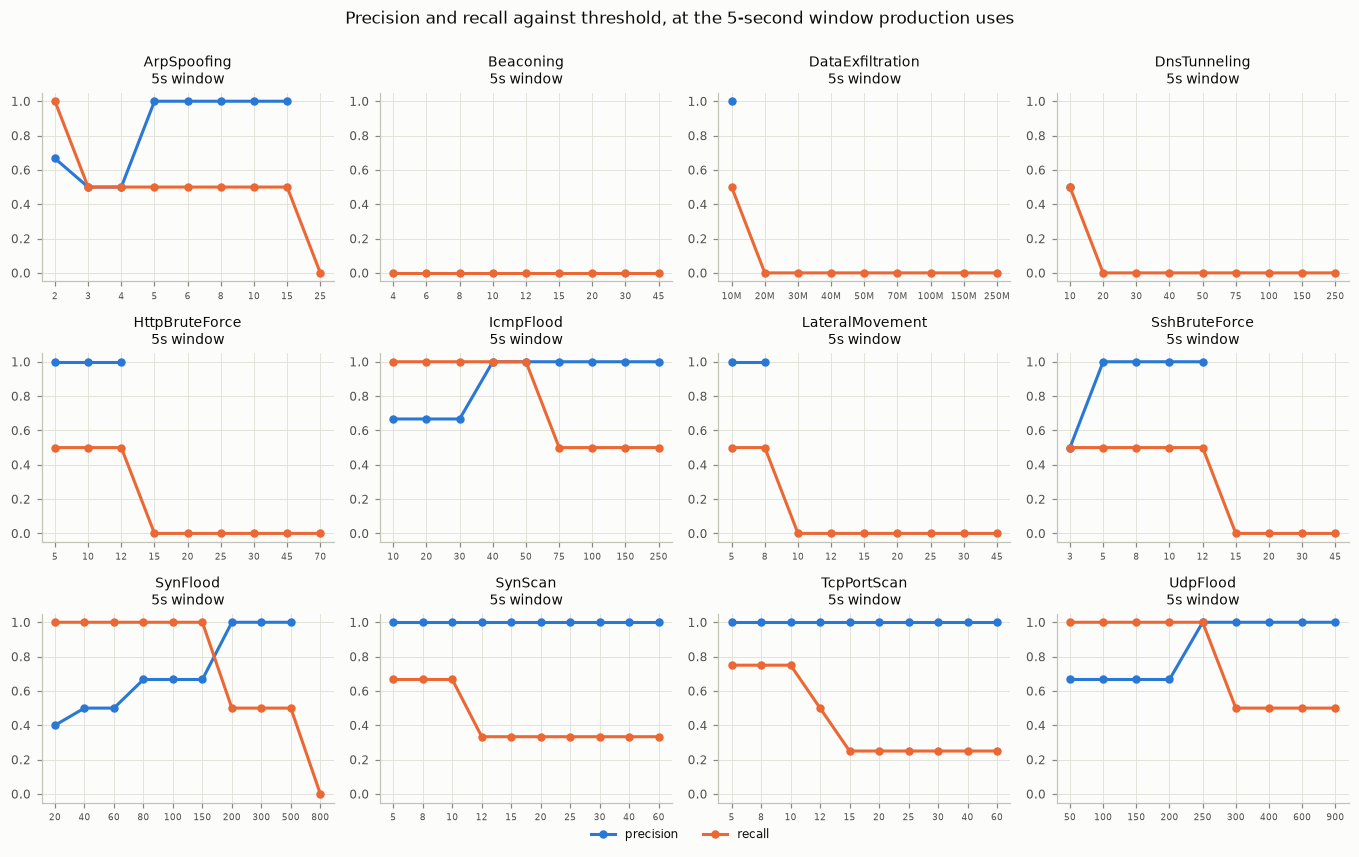

In [10]:
%matplotlib inline

from sensitivity.grid import THRESHOLDS, WINDOWS
from sensitivity.plots_curves import precision_recall_grid, roc_grid
from sensitivity.style import apply_style

apply_style()

shipped_curves = precision_recall_grid(
    metrics,
    dict.fromkeys(THRESHOLDS, SHIPPED_WINDOW),
    "Precision and recall against threshold, at the 5-second window production uses",
)

Read the orange lines. Five detectors sit flat on zero across their whole
threshold range: no setting of the number an operator is invited to tune moves
them, because the constraint is not the threshold. Three more start at 0.5 and
fall.

Now the same panels with each detector given the window its own configuration
asks for.

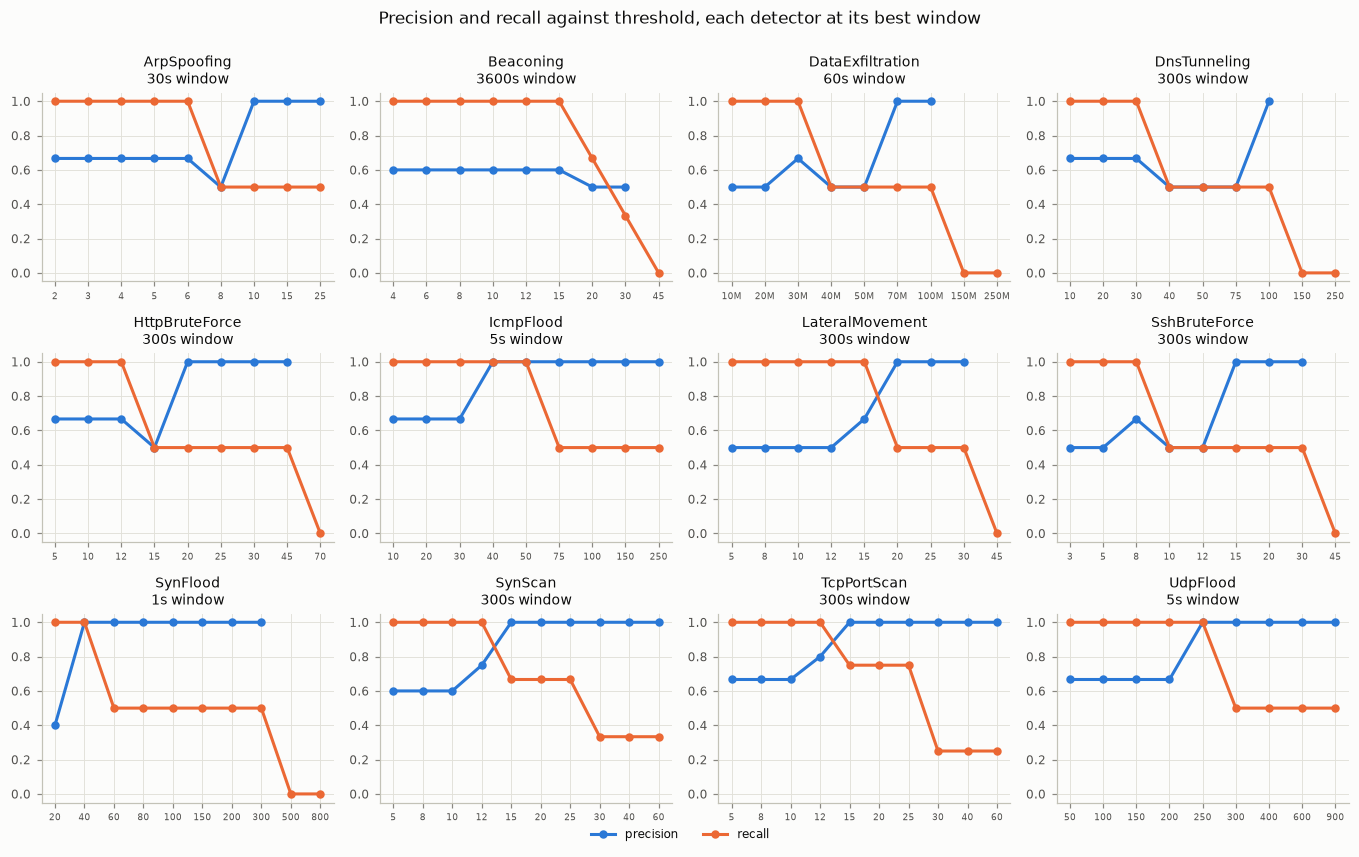

In [11]:
best_curves = precision_recall_grid(
    metrics,
    {name: float(best.loc[name, "window_seconds"]) for name in best.index},
    "Precision and recall against threshold, each detector at its best window",
)

Every panel now shows the trade-off the threshold is supposed to express:
recall falling as the threshold rises, precision climbing to meet it, and a
crossover somewhere in between. That crossover is the tuning decision, and at a
five-second window most detectors never reach one.

## 7. ROC-style curves

Recall against false-positive rate, one curve per evaluation window, with the
window encoded as an ordered ramp rather than as categorical colour — it is a
quantity, and light-to-dark reads as ordered without a legend lookup.

There is no chance diagonal. Every false-positive rate here is under 0.06,
because the corpus has forty-odd negative cases and a detector alerts on at
most two of them; on an axis clipped that far, a diagonal is not the chance
line, it is a line at the wrong slope inviting the wrong comparison.

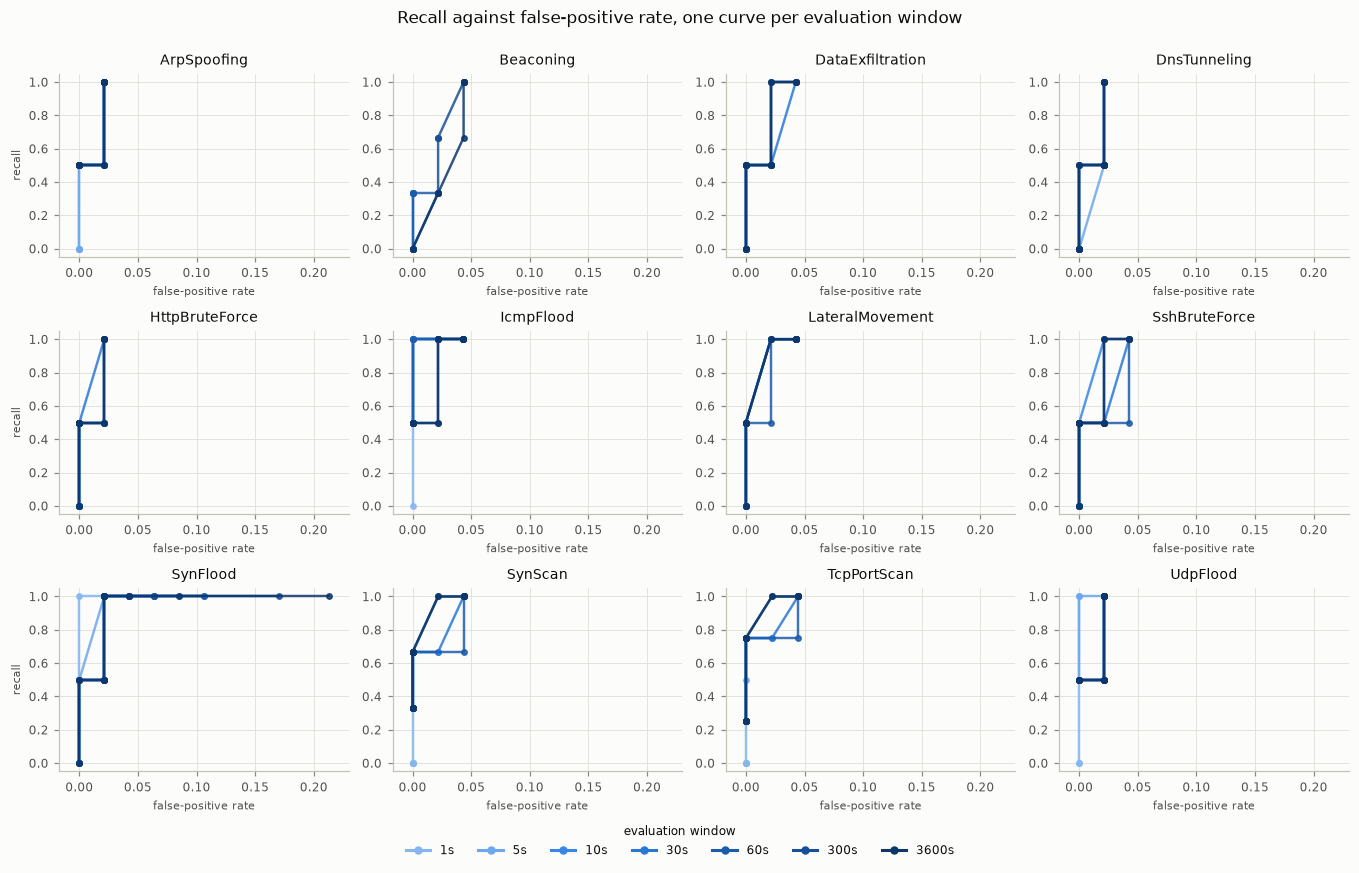

In [12]:
roc_curves = roc_grid(metrics, WINDOWS, "Recall against false-positive rate, one curve per evaluation window")

The dark curves sit above and to the left of the light ones in every panel
where the two differ, which is the same finding the tables give: lengthening
the window buys recall at almost no cost in false positives. The exceptions are
the three flood detectors, whose light curves are already in the top-left
corner — they are the detectors whose configured window and the implemented one
happen to agree.

Both figures are written to `docs/images/` by
`uv run python scripts/make_sensitivity_figures.py`.

## 8. Parameter sensitivity

The curves above hold the window fixed and vary the threshold. This varies
both, which is the only way to see which of the two the result is actually
sensitive to.

Colour is a single hue, light to dark, because F1 is a magnitude — a rainbow
would imply the middle of the range is a different *kind* of result rather
than a smaller one. Grey cells are not zero: they are configurations where the
detector never fired, so it has no score. The outlined row is the threshold
that ships today.

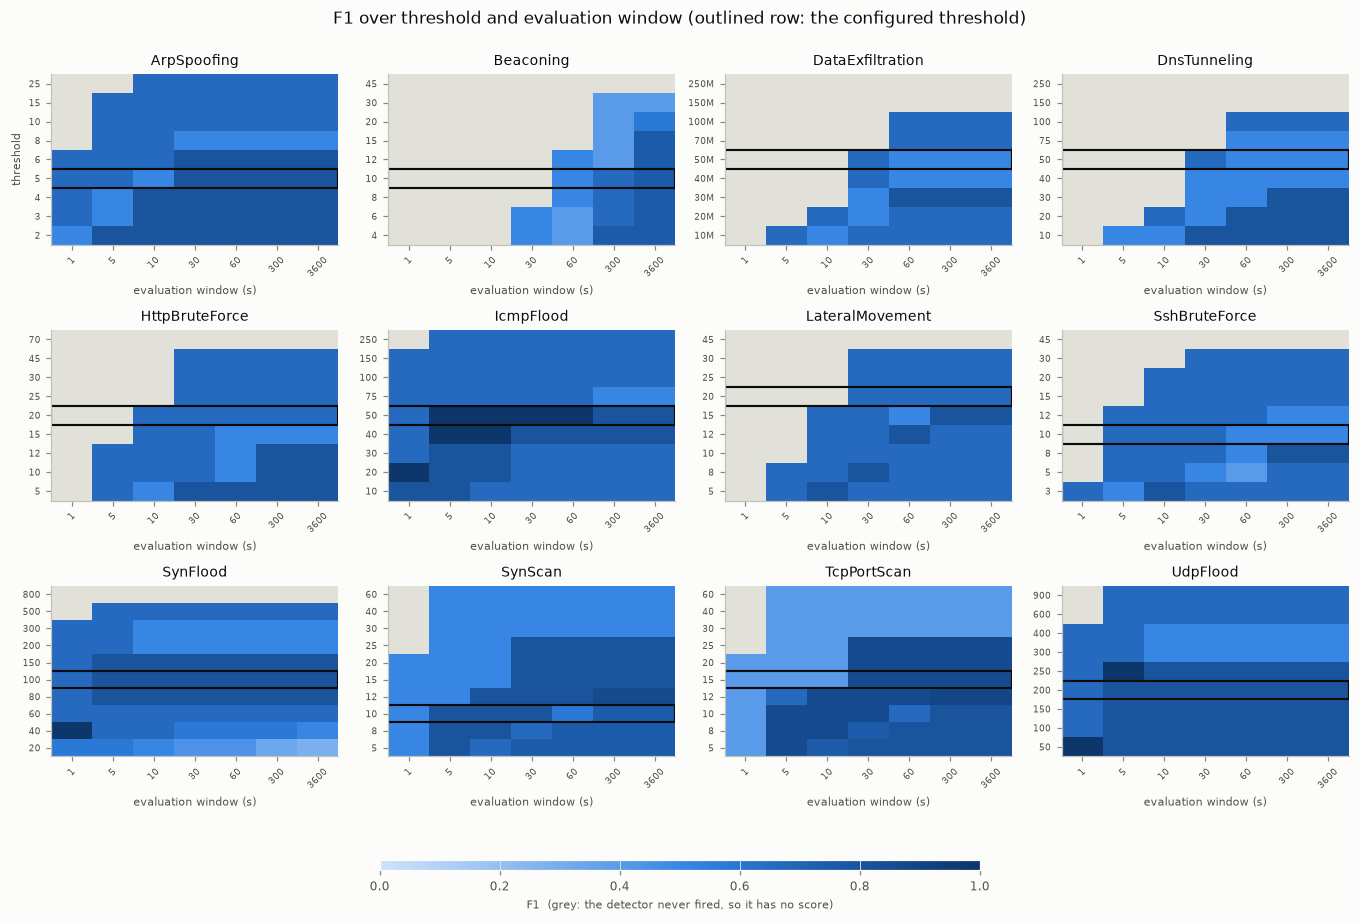

In [13]:
from sensitivity.detectors import shipped_value
from sensitivity.grid import THRESHOLDS as GRIDS
from sensitivity.plots_heatmaps import f1_heatmaps

heatmaps = f1_heatmaps(
    metrics,
    {name: float(shipped_value(name, parameter)) for name, (parameter, _) in GRIDS.items()},
    "F1 over threshold and evaluation window (outlined row: the configured threshold)",
)

Read the gradient direction. In nine of the twelve panels it runs left to
right — along the window — and the outlined row crosses grey or near-grey cells
at the left edge, which is where production sits. Only the three flood
detectors have a gradient that runs mostly up and down, and they are the three
whose configured window is short enough that the implementation happens to
match it.

That is the practical form of the finding. For most of these detectors, the
number an operator is invited to tune is the wrong knob: moving it along the
row changes very little compared with moving one column to the right.

## 9. What an analyst would actually see

Every number above is measured case by case, in isolation. That is what makes
precision and recall well-defined, and it is not what an operator experiences.
This section lays the same cases end to end on one clock — half an hour of
benign traffic with five attacks placed inside it — and asks how many alerts
arrive, when, and how many of them were about anything.

Two configurations over the identical packets: what ships today, and what the
sweep recommends. The recommendation has to name one evaluation interval, not
one per detector, because `PeriodicEvaluator` runs a single timer.

In [14]:
from sensitivity.plots_timeline import alert_volume
from sensitivity.recommendation import best_common_window, recommended_thresholds, window_scores
from sensitivity.scenario import DURATION, attack_spans

window_scores(metrics).round(3).rename("mean F1 across detectors, undefined counted as zero")

window_seconds
1.0       0.436
5.0       0.702
10.0      0.721
30.0      0.774
60.0      0.785
300.0     0.808
3600.0    0.808
Name: mean F1 across detectors, undefined counted as zero, dtype: float64

In [15]:
interval = best_common_window(metrics)
print(f"one interval for all detectors: {interval:g}s")
pd.Series(recommended_thresholds(metrics, interval)).rename("recommended threshold")

one interval for all detectors: 300s


ArpSpoofingDetector                6
BeaconingDetector                  4
DataExfiltrationDetector    30000000
DnsTunnelingDetector              30
HttpBruteForceDetector            12
IcmpFloodDetector                 50
LateralMovementDetector           15
SshBruteForceDetector              8
SynFloodDetector                 150
SynScanDetector                   12
TcpPortScanDetector               12
UdpFloodDetector                 250
Name: recommended threshold, dtype: int64

In [16]:
timeline = pd.read_csv("../research/alert_timeline.csv")
timeline.pivot_table(
    index="config", columns="attributable", values="detector", aggfunc="count"
).rename(columns={0: "nothing was happening", 1: "an attack was running"})

attributable,nothing was happening,an attack was running
config,,
recommended — 300s interval,16.0,7.0
shipped — 5s interval,NaN,4.0


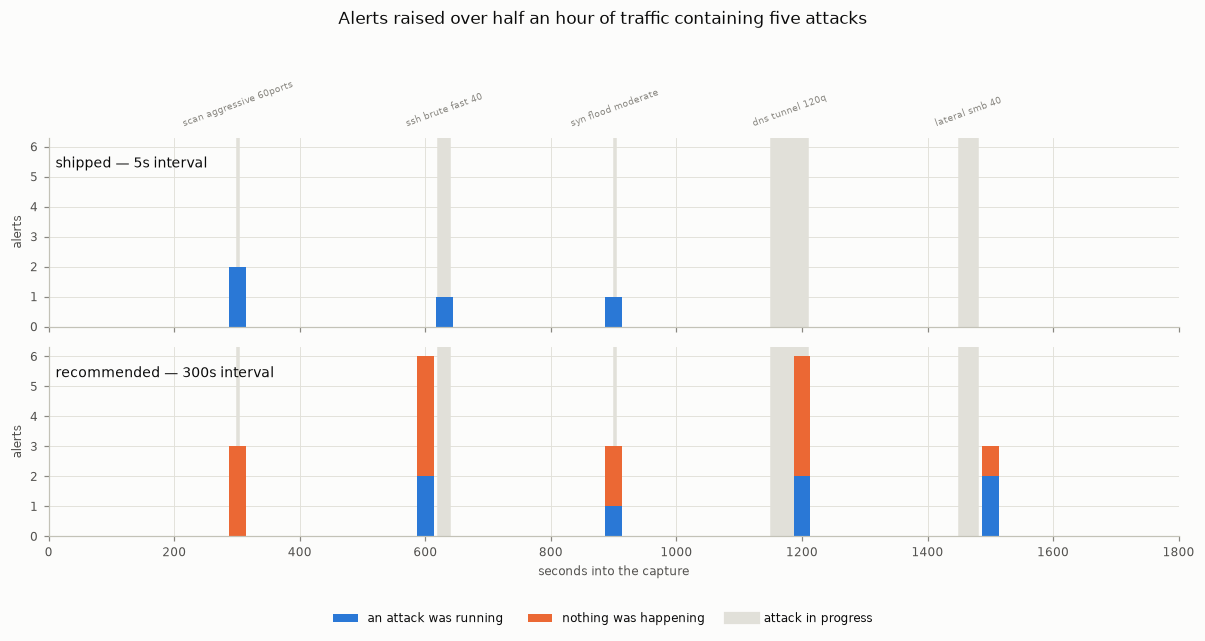

In [17]:
volume = alert_volume(
    timeline,
    attack_spans(),
    DURATION,
    "Alerts raised over half an hour of traffic containing five attacks",
)

This is the finding the sweep cannot show, and it cuts against the
recommendation.

What ships raises four alerts in half an hour and every one of them is real —
and it detects three of the five attacks, missing the DNS tunnel and the
lateral movement entirely. What the sweep recommends detects all five and
raises twenty-three alerts, sixteen of which are about nothing. On this corpus
that trade reads as an F1 improvement. On a real segment it reads as thirty-two
false alarms an hour, and the analyst stops looking.

The reason the sweep flatters it is that the corpus is half attacks. Production
is not: benign traffic outnumbers attacks by orders of magnitude, so every
false-positive rate here is multiplied by a much larger denominator than the
one it was measured against. A false-positive *rate* of 0.02 is a fine number
and roughly one alert per hour per detector on a busy segment.

The second cost is latency. A three-hundred-second interval means the port scan
at t=300 is reported at t=600 and the lateral movement at t=1450 at t=1500. The
window that buys recall is also the delay before anyone hears about it, and
nothing in an F1 score prices that.

Both are argued out in `docs/DETECTION_TUNING.md`, which is where the
recommendations that survive them are written down.